# Benchmark 5: read-your-writes staleness
Write to the leader, then poll a follower's full-table SELECT until the row appears. Run `bench/05-read-your-writes.sh` first.

In [ ]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load, agg


In [2]:
df = load("read-your-writes.csv")
df

,run,iteration,stalenessMs
0,1,1,19.5
1,1,2,20.9
2,1,3,19.0
3,1,4,18.4
4,1,5,18.4
5,1,6,20.3
6,1,7,19.7
7,1,8,18.2
8,1,9,17.8
9,1,10,19.0


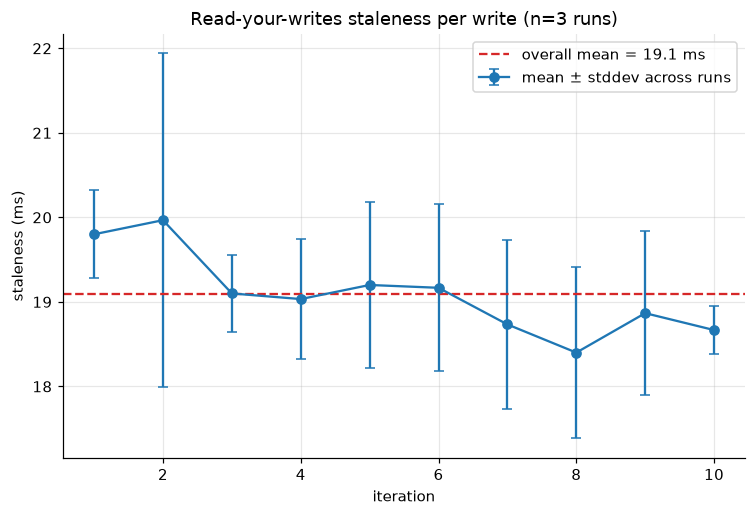

In [3]:
by_iteration = agg(df, ["iteration"], "stalenessMs")

fig, ax = plt.subplots()
ax.errorbar(by_iteration["iteration"], by_iteration["mean"], yerr=by_iteration["std"],
            marker="o", capsize=3, label="mean ± stddev across runs")
overall_mean = df["stalenessMs"].mean()
ax.axhline(overall_mean, color="tab:red", linestyle="--", label=f"overall mean = {overall_mean:.1f} ms")
ax.set_xlabel("iteration")
ax.set_ylabel("staleness (ms)")
ax.set_title(f"Read-your-writes staleness per write (n={df['run'].nunique()} runs)")
ax.legend()
plt.show()

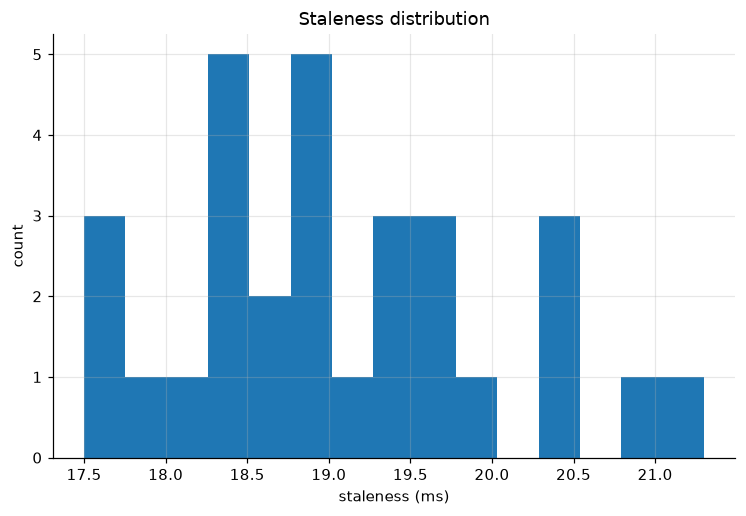

count    30.000000
mean     19.093333
std       0.949386
min      17.500000
25%      18.500000
50%      18.950000
75%      19.675000
max      21.300000
Name: stalenessMs, dtype: float64


In [4]:
fig, ax = plt.subplots()
ax.hist(df["stalenessMs"], bins=min(15, df['stalenessMs'].nunique()))
ax.set_xlabel("staleness (ms)")
ax.set_ylabel("count")
ax.set_title("Staleness distribution")
plt.show()
print(df["stalenessMs"].describe())